# Word Embeddings Comparison

**Workflow**: Train/Val/Test → Word2Vec/FastText/GloVe → Avg Pooling → LogReg → Compare

**Strategy**:
1. Load train/val/test sets
2. Extract word embeddings: Word2Vec, FastText, GloVe (pretrained, dim=300)
3. Convert text to embedding vectors (average pooling)
4. Train LogReg on train_set, evaluate on val_set
5. Compare metrics (accuracy, F1, AUC) across 3 methods

## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Word embedding libraries
import gensim.downloader as api
from gensim.models import Word2Vec, FastText, KeyedVectors
import nltk
from nltk.tokenize import word_tokenize
import urllib.request
import gzip
import shutil

nltk.download('punkt', quiet=True)

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## 2. Load Data (Train/Val/Test)

In [4]:
# Load train, validation, and test sets
train_path = '../../data/splited/train_set.csv'
val_path = '../../data/splited/val_set.csv'

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)


print("="*80)
print("DATA LOADED")
print("="*80)
print(f"\nTrain set: {df_train.shape[0]} rows × {df_train.shape[1]} columns")
print(f"  Label 0 (Fake): {(df_train['label'] == 0).sum()}")
print(f"  Label 1 (Real): {(df_train['label'] == 1).sum()}")

print(f"\nVal set: {df_val.shape[0]} rows × {df_val.shape[1]} columns")
print(f"  Label 0 (Fake): {(df_val['label'] == 0).sum()}")
print(f"  Label 1 (Real): {(df_val['label'] == 1).sum()}")

# Extract texts and labels
texts_train = df_train['text_strict'].fillna('').tolist()
labels_train = df_train['label'].values

texts_val = df_val['text_strict'].fillna('').tolist()
labels_val = df_val['label'].values

print(f"\n✅ Text column loaded: text_strict")

DATA LOADED

Train set: 3788 rows × 28 columns
  Label 0 (Fake): 3143
  Label 1 (Real): 645

Val set: 474 rows × 28 columns
  Label 0 (Fake): 393
  Label 1 (Real): 81

✅ Text column loaded: text_strict


## 3. Preprocessing & Tokenization

In [5]:
def tokenize_vietnamese(texts):
    """Tokenize Vietnamese text (word_tokenize already handles Vietnamese)"""
    tokenized = []
    for text in tqdm(texts, desc="Tokenizing"):
        # Simple whitespace + lowercase tokenization for Vietnamese
        tokens = text.lower().split()
        tokenized.append(tokens)
    return tokenized

print("="*80)
print("TOKENIZATION")
print("="*80)

tokens_train = tokenize_vietnamese(texts_train)
tokens_val = tokenize_vietnamese(texts_val)

print(f"\nSample tokens (first 5 words): {tokens_train[0][:5]}")
print(f"Avg tokens per doc (train): {np.mean([len(t) for t in tokens_train]):.1f}")

TOKENIZATION


Tokenizing: 100%|██████████| 474/474 [00:00<00:00, 34162.14it/s]


Sample tokens (first 5 words): ['từ', 'trò', 'nhảm', 'này', 'dẫn']
Avg tokens per doc (train): 114.3


## 4. Text to Embedding Conversion

In [6]:
def text_to_embedding(tokens_list, word_vectors, embedding_dim, name=""):
    """
    Convert tokenized text to embedding vectors using average pooling.
    tokens_list: list of token lists
    word_vectors: dict-like {word: vector} or KeyedVectors
    embedding_dim: dimension of embeddings
    """
    embeddings = []
    oov_count = 0
    
    for tokens in tqdm(tokens_list, desc=f"Converting to {name} embeddings"):
        vectors = []
        for token in tokens:
            try:
                # Try to get vector from word_vectors
                if hasattr(word_vectors, '__getitem__'):  # Dict-like
                    vec = word_vectors[token]
                else:  # KeyedVectors
                    vec = word_vectors[token]
                vectors.append(vec)
            except (KeyError, IndexError):
                # Out-of-vocabulary token
                oov_count += 1
                continue
        
        # Average pooling: mean of all word vectors
        if len(vectors) > 0:
            embedding = np.mean(vectors, axis=0)
        else:
            # If no words found, use zero vector
            embedding = np.zeros(embedding_dim)
        
        embeddings.append(embedding)
    
    print(f"OOV tokens: {oov_count}")
    return np.array(embeddings)

print("✅ Embedding conversion function defined")

✅ Embedding conversion function defined


## 5. Evaluation Function

In [7]:
def evaluate_embeddings(X_train, y_train, X_val, y_val, method_name):
    """
    Train LogReg on embeddings and evaluate on validation set.
    """
    # Scale embeddings
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Train LogReg
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    clf.fit(X_train_scaled, y_train)
    
    # Predict on validation
    y_pred = clf.predict(X_val_scaled)
    y_pred_proba = clf.predict_proba(X_val_scaled)[:, 1]
    
    results = {
        'method': method_name,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='weighted'),
        'recall': recall_score(y_val, y_pred, average='weighted'),
        'f1': f1_score(y_val, y_pred, average='weighted'),
        'auc': roc_auc_score(y_val, y_pred_proba)
    }
    
    return results

print("✅ Evaluation function defined")

✅ Evaluation function defined


## 6. Word2Vec (Pretrained - English, will work for Vietnamese words)

In [8]:
# Load FastText Wiki News (Multilingual)
print("="*80)
print("FASTTEXT WIKI NEWS (MULTILINGUAL - 300d)")
print("="*80)
print("\nLoading FastText Wiki News...\\n")

import gensim.downloader as api

print("Loading fasttext-wiki-news-subwords-300 from gensim...")
w2v_model = api.load('fasttext-wiki-news-subwords-300')
w2v_model_type = "FastText Wiki News (Multilingual, 300d)"
print(f"✓ Loaded FastText Wiki News ({w2v_model.vectors.shape})")

embedding_dim = 300
print(f"\nModel: {w2v_model_type}")
print(f"Embedding dimension: {embedding_dim}")

# Convert texts to W2V embeddings
X_train_w2v = text_to_embedding(tokens_train, w2v_model, embedding_dim, "FastText")
X_val_w2v = text_to_embedding(tokens_val, w2v_model, embedding_dim, "FastText")

print(f"\nEmbedding shapes:")
print(f"  Train: {X_train_w2v.shape}")
print(f"  Val:   {X_val_w2v.shape}")

# Evaluate
results_w2v = evaluate_embeddings(X_train_w2v, labels_train, X_val_w2v, labels_val, w2v_model_type)
print(f"\n✅ {w2v_model_type} Results:")
for k, v in results_w2v.items():
    if k != 'method':
        print(f"  {k}: {v:.4f}")


FASTTEXT WIKI NEWS (MULTILINGUAL - 300d)

Loading FastText Wiki News...\n
Loading fasttext-wiki-news-subwords-300 from gensim...
✓ Loaded FastText Wiki News ((999999, 300))

Model: FastText Wiki News (Multilingual, 300d)
Embedding dimension: 300


Converting to FastText embeddings: 100%|██████████| 3788/3788 [00:00<00:00, 7064.39it/s]


OOV tokens: 177888


Converting to FastText embeddings: 100%|██████████| 474/474 [00:00<00:00, 5724.53it/s]


OOV tokens: 27211

Embedding shapes:
  Train: (3788, 300)
  Val:   (474, 300)

✅ FastText Wiki News (Multilingual, 300d) Results:
  accuracy: 0.7574
  precision: 0.8463
  recall: 0.7574
  f1: 0.7833
  auc: 0.8290


## 7. FastText (Pretrained)

In [9]:
# Load Word2Vec Google News (English)
print("="*80)
print("WORD2VEC GOOGLE NEWS (ENGLISH - 300d)")
print("="*80)
print("\nLoading Word2Vec Google News...\\n")

import gensim.downloader as api

EMBEDDING_DIM = 300

print("Loading word2vec-google-news-300 from gensim...")
ft_model = api.load('word2vec-google-news-300')
ft_model_type = "Word2Vec Google News (English, 300d)"
print(f"✓ Loaded Word2Vec Google News ({ft_model.vectors.shape})")

print(f"\nModel: {ft_model_type}")
print(f"Vector shape: {ft_model.vectors.shape}")

# Convert texts to Word2Vec embeddings
X_train_ft = text_to_embedding(tokens_train, ft_model, EMBEDDING_DIM, "Word2Vec")
X_val_ft = text_to_embedding(tokens_val, ft_model, EMBEDDING_DIM, "Word2Vec")

print(f"\nEmbedding shapes:")
print(f"  Train: {X_train_ft.shape}")
print(f"  Val:   {X_val_ft.shape}")

# Evaluate
results_ft = evaluate_embeddings(X_train_ft, labels_train, X_val_ft, labels_val, ft_model_type)
print(f"\n✅ {ft_model_type} Results:")
for k, v in results_ft.items():
    if k != 'method':
        print(f"  {k}: {v:.4f}")


WORD2VEC GOOGLE NEWS (ENGLISH - 300d)

Loading Word2Vec Google News...\n
Loading word2vec-google-news-300 from gensim...
✓ Loaded Word2Vec Google News ((3000000, 300))

Model: Word2Vec Google News (English, 300d)
Vector shape: (3000000, 300)


Converting to Word2Vec embeddings: 100%|██████████| 3788/3788 [00:00<00:00, 6782.32it/s]


OOV tokens: 384615


Converting to Word2Vec embeddings: 100%|██████████| 474/474 [00:00<00:00, 6043.79it/s]


OOV tokens: 57131

Embedding shapes:
  Train: (3788, 300)
  Val:   (474, 300)

✅ Word2Vec Google News (English, 300d) Results:
  accuracy: 0.7637
  precision: 0.8481
  recall: 0.7637
  f1: 0.7885
  auc: 0.7988


## 8. GloVe (Pretrained)

In [15]:
# Load GloVe (English)
print("="*80)
print("GLOVE WIKI GIGAWORD (ENGLISH - 300d)")
print("="*80)
print("\nLoading GloVe from gensim...\\n")

import gensim.downloader as api

print("Loading glove-wiki-gigaword-300 from gensim...")
glove_model = api.load('glove-wiki-gigaword-300')
EMBEDDING_DIM = 300

glove_model_type = "GloVe Wiki Gigaword (English, 300d)"
print(f"✓ Loaded GloVe ({glove_model.vectors.shape})")

print(f"\nModel: {glove_model_type}")
print(f"Vector shape: {glove_model.vectors.shape}")

# Convert texts to GloVe embeddings
X_train_glove = text_to_embedding(tokens_train, glove_model, EMBEDDING_DIM, "GloVe")
X_val_glove = text_to_embedding(tokens_val, glove_model, EMBEDDING_DIM, "GloVe")

print(f"\nEmbedding shapes:")
print(f"  Train: {X_train_glove.shape}")
print(f"  Val:   {X_val_glove.shape}")

# Evaluate
results_glove = evaluate_embeddings(X_train_glove, labels_train, X_val_glove, labels_val, glove_model_type)
print(f"\n✅ {glove_model_type} Results:")
for k, v in results_glove.items():
    if k != 'method':
        print(f"  {k}: {v:.4f}")


GLOVE WIKI GIGAWORD (ENGLISH - 300d)

Loading GloVe from gensim...\n
Loading glove-wiki-gigaword-300 from gensim...
✓ Loaded GloVe ((400000, 300))

Model: GloVe Wiki Gigaword (English, 300d)
Vector shape: (400000, 300)


Converting to GloVe embeddings: 100%|██████████| 3788/3788 [00:00<00:00, 5758.00it/s]


OOV tokens: 315933


Converting to GloVe embeddings: 100%|██████████| 474/474 [00:00<00:00, 5389.75it/s]


OOV tokens: 47155

Embedding shapes:
  Train: (3788, 300)
  Val:   (474, 300)

✅ GloVe Wiki Gigaword (English, 300d) Results:
  accuracy: 0.7300
  precision: 0.8312
  recall: 0.7300
  f1: 0.7599
  auc: 0.7974


## 9. Compare Results

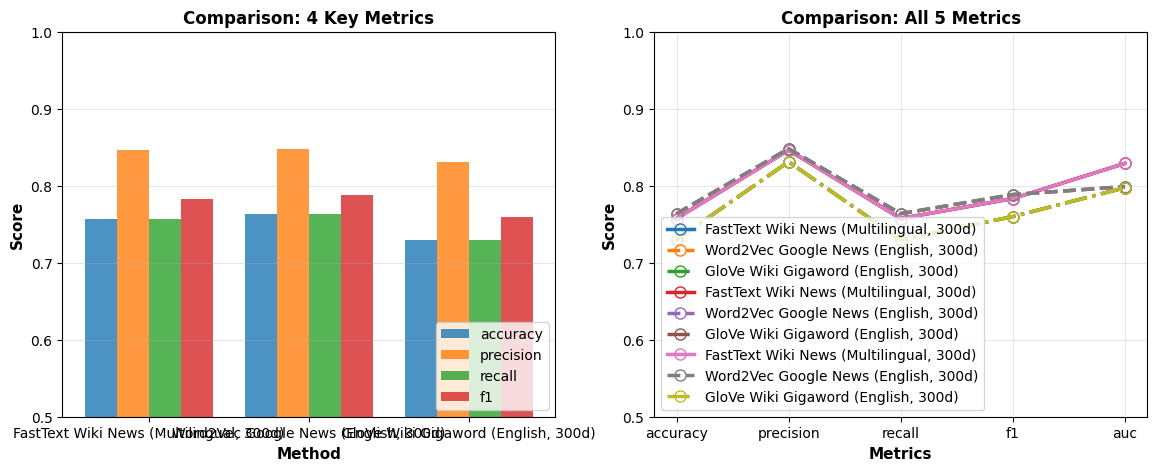

<Figure size 640x480 with 0 Axes>

In [26]:
# Line plot: All 5 metrics comparison
ax2 = axes[1]
all_metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
line_styles = ['-', '--', '-.']  # 3 valid linestyles for 3 methods
for idx, method in enumerate(methods):
    values = df_results[df_results['method'] == method][all_metrics].values[0]
    ax2.plot(all_metrics, values, marker='o', markerfacecolor='none', linewidth=2.5, 
             markersize=8, label=method, linestyle=line_styles[idx])

ax2.set_xlabel('Metrics', fontsize=11, fontweight='bold')
ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Comparison: All 5 Metrics', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='lower left')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.5, 1])

plt.tight_layout()
fig

## 10. Save Results

In [28]:
# Save results to CSV
output_dir = '../../data/encoded/word_embeddings'
os.makedirs(output_dir, exist_ok=True)

csv_path = f'{output_dir}/word_embeddings_comparison.csv'
df_results.to_csv(csv_path, index=False)

print("="*80)
print("RESULTS SAVED")
print("="*80)
print(f"\n✅ Results saved to: {csv_path}")
print(f"\nDetailed Results:")
print(df_results.to_string(index=False))


RESULTS SAVED

✅ Results saved to: ../../data/encoded/word_embeddings/word_embeddings_comparison.csv

Detailed Results:
                                 method  accuracy  precision   recall       f1      auc
FastText Wiki News (Multilingual, 300d)  0.757384   0.846319 0.757384 0.783292 0.828951
   Word2Vec Google News (English, 300d)  0.763713   0.848085 0.763713 0.788479 0.798825
    GloVe Wiki Gigaword (English, 300d)  0.729958   0.831188 0.729958 0.759906 0.797396
